---
title: Simulate time evolution of the transverse-field Ising model
description: Use Qiskit.jl to simulate time evolution of the transverse-field Ising model on IBM Quantum hardware
---

{/* cspell:ignore mktempdir Néel spdiagm Runge Kutta tspan saveat siteinds Neel maxdim tensornetworkstate println countmap clims xlabel ylabel colorbar juliaup vcat nsteps ylims topright findfirst */}

# Simulate time evolution of the transverse-field Ising model
Usage estimate: 22 seconds on Heron r2 processor (NOTE: This is an estimate only. Your runtime may vary.)

## Learning outcomes
1. Learn how to transpile and run quantum circuits on the hardware using Julia
2. Learn how to post-process measurement outcomes to compute expectation values
3. Learn how to benchmark hardware results against classical simulation to quantify the combined effects of Trotter approximation error and hardware noise

## Prerequisites

We suggest that users get familiar with the following topics before going through this tutorial:
* [Quantum simulation for time evolution](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-simulation)

* [The transverse field Ising model](https://en.wikipedia.org/wiki/Transverse-field_Ising_model)

* [Circuit transpilation in Qiskit](https://quantum.cloud.ibm.com/docs/en/guides/transpile#introduction-to-transpilation)

## Background

Julia is a dynamic programming language designed primarily for numerical and scientific computing. Its high-performance numerical computing capabilities make it a natural fit for quantum simulation workflows. In this tutorial, we will show how Julia is used for both classical pre- and post-processing (e.g., building Hamiltonians, running ODE solvers, computing expectation values) and for orchestrating quantum hardware jobs, eliminating the need to switch between languages or environments.

To interface with IBM Quantum hardware from Julia, this tutorial uses two packages from the Qiskit ecosystem: `Qiskit.jl` wraps the Qiskit C library and provides circuit construction and transpilation functionality in Julia; `QiskitIBMRuntime.jl` connects to IBM Quantum hardware through the Qiskit IBM Runtime service, enabling job submission and result retrieval directly from Julia.

In this tutorial, we consider the trotterized evolution of the transverse-field Ising model on a 1D chain with nearest-neighbor interactions:

$$
    H = \sum_{\langle i,j\rangle}J_{ij}Z_iZ_j + \sum_i h_i X_i
$$

To implement the time evolution $e^{-iH\tau}$, we divide the time interval $\tau$ into $r$ steps and define $\Delta\tau=\tau/r$. The second-order Trotter-Suzuki decomposition gives:
$$
    e^{-iH\Delta\tau}\approx \prod_i e^{-ih_i X_i\Delta\tau/2 } \prod_{\langle i,j\rangle} e^{-iJ_{ij}Z_iZ_j\Delta\tau} \prod_i e^{-ih_iX_i\Delta\tau/2}
$$

For circuit construction, each Trotter step is implemented as a sequence of single-qubit $R_x$ rotations and two-qubit $R_{ZZ}$ gates. The circuit begins by preparing the Néel state $|0101\cdots\rangle$ using X gates on alternating qubits. Each subsequent Trotter step applies: (1) $R_x(h_i\Delta\tau)$ on every qubit, (2) $R_{ZZ}(2J_{ij}\Delta\tau)$ on each neighboring pair along the chain, and (3) $R_x(h_i\Delta\tau)$ again on every qubit. The total circuit depth grows linearly with the number of Trotter steps $r$.

## Requirements

Note that this tutorial requires macOS or Linux — Qiskit.jl is not currently supported on Windows (tracked in [this open issue](https://github.com/Qiskit/Qiskit.jl/issues/15)).

To get started, install Julia, following the instructions on the [Julia download page](https://julialang.org/downloads/). This tutorial was developed with Julia 1.11; install it with `juliaup add 1.11`.

Then, run the following command in a terminal to install the Julia package `IJulia` into the global environment, which lets you run Julia inside the Jupyter notebook.

```
julia -e 'using Pkg; Pkg.add("IJulia")'
```

We will use Julia's built-in package manager to set up the project environment. There are two ways to set up the environment.

*Option 1*: temporary environment. You can run the following code cell to set up a temporary environment and install the required packages;

*Option 2*: reproduce the exact tested environment. Set `download_toml_files = true` in the cell below. The cell will download `Project.toml` and `Manifest.toml` from the documentation [repository](https://github.com/Qiskit/documentation/tree/main/docs/tutorials/assets/time-evolution/julia) into an `env_tutorial/time-evolution/` folder next to this notebook, then activate that environment and install the exact package versions it records. The project file describes the environment at a high level, for example, the `[deps]` section lists all dependencies. The manifest file pins the precise version of every package (including indirect dependencies), which is what makes the environment reproducible. See the [Julia documentation](https://pkgdocs.julialang.org/v1/toml-files/) for more on these files.

The following dependencies will be installed in the environment,

For quantum circuit construction and execution:
* `Qiskit.jl`
* `QiskitIBMRuntime.jl`

For classical simulation:
* `OrdinaryDiffEq.jl`
* `TensorNetworkQuantumSimulator.jl`

For post-processing results and visualization:
* `StatsBase.jl`
* `JSON.jl`
* `Plots.jl`

Note that `Qiskit.jl` is pinned to the 0.4 series. Version 0.5 tracks a newer release of the underlying Qiskit C library whose circuit-parameter representation `QiskitIBMRuntime.jl` does not yet read correctly, which causes gate rotation angles to be lost when a job is submitted. Because 0.4 predates the `Qiskit.Operations` submodule, this notebook builds circuits with the property-style API (`qc.rx(θ, i)`) rather than the `!`-suffixed functions (`rx!(qc, θ, i)`).

In [1]:
using Pkg

devdir = joinpath(homedir(), ".julia", "dev")
env_dir = joinpath(homedir(), "envs", "qkrtc-test")
Pkg.activate(env_dir)

Pkg.develop([
    PackageSpec(path=joinpath(devdir, "qiskit_ibm_runtime_jll")),
    PackageSpec(path=joinpath(devdir, "Qiskit")),
    PackageSpec(path=joinpath(devdir, "QiskitIBMRuntime")),
])

Pkg.add([
    PackageSpec(name="Python_jll", version="3.11"),
    PackageSpec(name="OrdinaryDiffEq"),
    PackageSpec(name="TensorNetworkQuantumSimulator"),
    PackageSpec(name="JSON"),
    PackageSpec(name="Plots"),
    PackageSpec(name="StatsBase"),
])

Pkg.status(["Qiskit", "QiskitIBMRuntime", "qiskit_ibm_runtime_jll"])
run(`git -C $(joinpath(devdir, "QiskitIBMRuntime")) branch --show-current`)

  Activating project at `~/envs/qkrtc-test`
   Resolving package versions...
  No Changes to `~/envs/qkrtc-test/Project.toml`
  No Changes to `~/envs/qkrtc-test/Manifest.toml`
   Resolving package versions...
  No Changes to `~/envs/qkrtc-test/Project.toml`
  No Changes to `~/envs/qkrtc-test/Manifest.toml`
Precompiling project...
   2208.9 ms  ✓ OrdinaryDiffEqDifferentiation
   1822.8 ms  ✓ OrdinaryDiffEqDifferentiation → OrdinaryDiffEqDifferentiationSparseArraysExt
   3582.5 ms  ✓ OrdinaryDiffEqNonlinearSolve
   7880.4 ms  ✓ OrdinaryDiffEqTsit5
  19692.8 ms  ✓ OrdinaryDiffEqVerner
  23296.8 ms  ✓ OrdinaryDiffEqRosenbrock
  24535.5 ms  ✓ OrdinaryDiffEqSDIRK
  18894.4 ms  ✓ OrdinaryDiffEqBDF
  48380.1 ms  ✓ OrdinaryDiffEqDefault
   4458.0 ms  ✓ OrdinaryDiffEq
  10 dependencies successfully precompiled in 106 seconds. 480 already precompiled.


Status `~/envs/qkrtc-test/Project.toml`
  [91d9a17d] Qiskit v0.5.1 `~/.julia/dev/Qiskit`
  [1f74880b] QiskitIBMRuntime v0.2.1 `~/.julia/dev/QiskitIBMRuntime`
  [dfd00f80] qiskit_ibm_runtime_jll v0.38.2+0 `~/.julia/dev/qiskit_ibm_runtime_jll`
recent-qkrtc


Process(`git -C /Users/haimengzhang/.julia/dev/QiskitIBMRuntime branch --show-current`, ProcessExited(0))

Up to this point, we have set up the Julia project environment to run the notebook. In order to run the workflow on IBM's quantum processing unit, an IBM Quantum account and API token are also required to instantiate Service from Qiskit IBM Runtime. Follow the "Install and authenticate" steps in the [IBM Quantum getting started guide](https://quantum.cloud.ibm.com/docs/en/guides/hello-world) to generate your API token and find your instance CRN — the account setup steps apply regardless of programming language.

## Setup

In [2]:
using Qiskit
using Qiskit.Operations
using QiskitIBMRuntime
using StatsBase
using OrdinaryDiffEq
using SparseArrays
using LinearAlgebra
using TensorNetworkQuantumSimulator
using Dates
using JSON
using Plots: plot, plot!, heatmap, @layout, mm

We will also define the following utility function which returns the value of the bit in a bitstring `v` at position `i`. For example, with `v = 6` (binary `110`),
- `bit_at(6, 1)` returns `0`,
- `bit_at(6, 2)` returns `1`,
- `bit_at(6, 3)` returns `1`.

This follows Qiskit's little endian convention, i.e., the position `i` is indexed from the least-significant (the "rightmost") bit.

In [3]:
"""
    bit_at(v::Integer, i::Integer) = (v >> (i-1)) & 1

Return the value of the bit at position `i` in `v`.
"""
bit_at(v::Integer, i::Integer) = (v >> (i-1)) & 1

bit_at

## Small-scale simulator example

We consider a 1D chain of $N$ qubits, described by the transverse-field Ising model above. For the system of interest, we specify below the system size `N`, the Trotter step size `δt`, and the total number of Trotter steps `r_max`. The total evolution time is `δt * r_max`. Note that Julia supports Unicode identifiers such as `δt`; in the notebook or Julia REPL, type `\delta` followed by Tab to enter `δ`. For a full reference, see the [Julia Unicode input documentation](https://docs.julialang.org/en/v1/manual/unicode-input/).

### Exact solution
To establish a baseline for comparing results from the quantum hardware, we first demonstrate the classical simulation workflow for a small-scale problem. We build the Ising Hamiltonian as a sparse matrix, then obtain the exact time evolution by numerically integrating the Schrödinger equation using `ODEProblem` from `OrdinaryDiffEq.jl`. This approach scales exponentially in the number of qubits $N$. It requires storing the full $2^N$-dimensional state vector. For $N=20$ the Hilbert space already has over one million dimensions, making it impractical for larger systems.

In [4]:
N = 20
δt = 0.05 # Trotter step size
r_max = 10 # total number of Trotter steps

h = fill(1.0, N)
J = fill(1.0, N-1)

# Build the Ising Hamiltonian as a sparse 2^n × 2^n matrix
function build_ising_hamiltonian(h::AbstractVector{<:Real}, J::AbstractVector{<:Real}, n::Int)
    dim = 2^n

    # diagonal ZZ terms
    diag_terms = zeros(Float64, dim)
    for i in 1:n-1
        for b in 0:dim-1
            bi = bit_at(b, i) # bit at position i
            bi_next = bit_at(b, i+1) # bit at position i + 1
            diag_terms[b+1] += J[i] * (1-2bi) * (1-2bi_next)
        end
    end
    H = spdiagm(0 => complex(diag_terms))

    # off-diagonal local X terms
    for i in 1:n
        mask = 1 << (i-1)
        cols = [xor(b, mask) + 1 for b in 0:dim-1]
        H += h[i] * sparse(1:dim, cols, ones(ComplexF64, dim), dim, dim)
    end
    return H
end

H_ising = build_ising_hamiltonian(h, J, N)

1048576×1048576 SparseMatrixCSC{ComplexF64, Int64} with 22020096 stored entries:
⎡⣿⣿⣾⢦⡀⠳⣄⠀⠀⠀⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠺⣟⢻⣶⣿⡂⠈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⢤⡈⠻⠻⠿⣧⣤⣠⡈⠳⠄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠙⢦⡀⠀⣻⣿⣿⣙⣦⡀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠙⢦⡈⠳⣼⣿⣿⡆⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠙⢦⡀⠀⠀⠁⠀⠈⠈⠉⣿⣿⣾⢦⡀⠳⣄⠀⠀⠈⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠺⣟⢻⣶⣿⡂⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⢤⡈⠻⠻⠿⣧⣤⣠⡈⠳⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡀⠀⣻⣿⣿⣙⣦⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡈⠳⣼⣿⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⎥
⎢⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣿⡟⢦⡈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠻⣍⣿⣿⣯⠀⠈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢦⡈⠋⠛⢻⣶⣦⣦⡈⠓⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠨⣿⠿⣧⣽⡦⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡀⠀⠀⠙⢦⠈⠳⡿⣿⣿⣀⡀⡀⠀⢀⠀⠀⠈⠳⣄⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠸⣿⣿⡟⢦⡈⠳⣄⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠈⠻⣍⣿⣿⣯⠀⠈⠳⣄⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠐⢦⡈⠋⠛⢻⣶⣦⣦⡈⠓⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡀⠨⣿⠿⣧⣽⡦⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⠀⠀⠀⠙⢦⠈⠳⡿⣿⣿⎦

We define the right-hand side of the Schrödinger equation in the in-place form `schrodinger!(dψ, ψ, H, t)`, which computes $d\psi/dt = -iH\psi$ using a sparse matrix-vector multiplication. We then set up an `ODEProblem` with the Néel state as the initial condition and solve it over the time span $[0, r \cdot \delta t]$, saving the state at each time step $\delta t$. The solver used is `Tsit5()`, a standard explicit 4th/5th-order Runge-Kutta method suitable for non-stiff problems.

In [5]:
# initial state |0101...01⟩
ψ0 = zeros(ComplexF64, 2^N)
neel_index = sum(1 << (i-1) for i in 1:2:N)
ψ0[neel_index + 1] = 1.0

function schrodinger!(dψ::AbstractVector, ψ::AbstractVector, H::AbstractMatrix, t::Real)
    mul!(dψ, H, ψ)
    dψ .*= -im
end

tspan = (0.0, r_max * δt)
prob = ODEProblem(schrodinger!, ψ0, tspan, H_ising)
sol = solve(prob, Tsit5(), saveat=δt)

retcode: Success
Interpolation: 1st order linear
t: 11-element Vector{Float64}:
 0.0
 0.05
 0.1
 0.15
 0.2
 0.25
 0.3
 0.35
 0.4
 0.45
 0.5
u: 11-element Vector{Vector{ComplexF64}}:
 [0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im  …  0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im]
 [-7.612535273941701e-14 - 4.337975683134715e-29im, 7.616818423232253e-14 - 1.6944517510822466e-12im, -8.56590334904389e-17 + 3.2368190823993754e-15im, -7.616820795844339e-14 - 1.0785153269116834e-15im, 1.5233638431199477e-13 - 1.6912125988569532e-12im, 3.5867824743714475e-11 + 5.083352813839523e-12im, -7.60824975249529e-14 - 4.317561743447094e-15im, 7.616820798431786e-14 - 1.6944516451719738e-12im, -8.570258514925326e-17 + 3.238411362418797e-15im, -7.606534127496745e-14 - 5.398093819616772e-15im  …  -7.591102113501633e-14 - 7.555016669022241e-15i

From the solution which describes the state vector $\psi(t)$, we can obtain the magnetization per site, expressed as the single-qubit $\langle Z\rangle$ expectation values as a function of time. We will compare this with the results obtained from the Trotterized circuits.

In [6]:
# get a single-qubit expectation value ⟨Z_qubit⟩ from a full state vector, weighting ±1 by |amplitude|²
function z_expval_from_state(ψ::AbstractVector{<:Complex}, qubit::Int, n::Int)
    s = 0.0
    for b in 0:2^n-1
        bit = bit_at(b, qubit)
        s += (1 - 2bit) * abs2(ψ[b+1])
    end
    return s
end

classical_magnetizations = [z_expval_from_state(sol.u[r+1], q, N)
                             for r in 0:r_max, q in 1:N]

11×20 Matrix{Float64}:
 -1.0       1.0       -1.0       1.0       …  1.0       -1.0       1.0
 -0.995021  0.995034  -0.995034  0.995034     0.995034  -0.995034  0.995021
 -0.980189  0.980386  -0.980386  0.980386     0.980386  -0.980386  0.980189
 -0.955994  0.956968  -0.956968  0.956968     0.956968  -0.956968  0.955994
 -0.922667  0.925652  -0.925653  0.925653     0.925653  -0.925652  0.922667
 -0.881106  0.888117  -0.88812   0.88812   …  0.88812   -0.888117  0.881106
 -0.832251  0.846116  -0.846129  0.846129     0.846129  -0.846116  0.832251
 -0.776957  0.801257  -0.801298  0.801298     0.801298  -0.801257  0.776957
 -0.715858  0.754749  -0.75486   0.75486      0.75486   -0.754749  0.715858
 -0.649744  0.707628  -0.707895  0.707895     0.707895  -0.707628  0.649744
 -0.580117  0.661272  -0.661841  0.661842  …  0.661841  -0.661272  0.580117

### Small-scale simulation of the Trotterized circuits

In the following, we show the classical simulation of the noiseless circuits using tensor network methods supported by `TensorNetworkQuantumSimulator.jl`. This allows us to validate our circuit construction and provides a baseline to compare with results from the quantum hardware.

We first define the lattice as a 1D chain graph using `named_grid((N,))`, where each vertex is a tuple `(i,)`. We then specify the circuit gates as a list of tuples `(gate_name, qubit_indices, gate_parameter)`, which serves as the input format for the tensor network simulator.

In [7]:
# 1D chain graph — vertices are named (1,), (2,), ..., (N,)
g = named_grid((N,))

# Gates to prepare Néel state |0101…⟩, X on every other site
neel_state_gates(n::Int) = [("X", [(i,)]) for i in 1:2:n]

# Gates for one second-order Trotter step of size δt
trotter_step_gates(h::AbstractVector{<:Real}, J::AbstractVector{<:Real}, n::Int, δt::Real) = vcat(
    [("Rx",  [(i,)],         h[i] * δt) for i in 1:n],
    [("Rzz", [(i,), (i+1,)], 2 * J[i] * δt) for i in 1:n-1],
    [("Rx",  [(i,)],         h[i] * δt) for i in 1:n])

# Make a list of gates: Néel state preparation followed by n_trotter_steps Trotter steps
function make_trotter_circuit_tn(h::AbstractVector{<:Real}, J::AbstractVector{<:Real}, n::Int, δt::Real,
                                 n_trotter_steps::Int)
    circuit = []

    # Neel state initialization
    append!(circuit, neel_state_gates(n))

    for _ in 1:n_trotter_steps
        append!(circuit, trotter_step_gates(h, J, n, δt))
    end

    return circuit
end

make_trotter_circuit_tn (generic function with 1 method)

We use the belief propagation algorithm for tensor network contraction. This method is efficient for circuits with limited entanglement, but its accuracy degrades as entanglement grows with circuit depth. The `maxdim` and `cutoff` parameters control the trade-off between accuracy and computational cost. Similarly, we compute the magnetization at each site to compare later.

In [8]:
apply_kwargs = (; maxdim=32, cutoff=1e-10, normalize_tensors=true)
tn_magnetizations = zeros(r_max+1, N)

# |↑↑…↑⟩ product state, wrapped in a belief propagation cache
tn_initial_state(g::NamedGraph) = BeliefPropagationCache(
    tensornetworkstate(ComplexF32, v -> "↑", g, "S=1/2"))

# Apply a gate list to a TN state; returns the evolved state and the
# truncation fidelity, i.e. ∏(1 - ε) over all gate applications
function apply_gates_to_tn_state(circuit::Vector, ψ_bpc::BeliefPropagationCache; apply_kwargs::NamedTuple)
    ψ_bpc, errs = apply_gates(circuit, ψ_bpc; apply_kwargs)
    return ψ_bpc, prod(1.0 .- errs)
end

# ⟨Z_q⟩ on every site of a tensor-network state
z_expvals_from_tn_state(ψ_bpc::BeliefPropagationCache, n::Int) =
    [real(expect(ψ_bpc, [("Z", [(q,)])])[1]) for q in 1:n]

for r in 0:r_max
    circuit = make_trotter_circuit_tn(h, J, N, δt, r)
    ψ_bpc, fidelity = apply_gates_to_tn_state(circuit, tn_initial_state(g); apply_kwargs)
    println("fidelity at Trotter step $(r) was $(fidelity)")
    tn_magnetizations[r+1, :] = z_expvals_from_tn_state(ψ_bpc, N)
end

fidelity at Trotter step 0 was 1.0
fidelity at Trotter step 1 was 1.0
fidelity at Trotter step 2 was 1.0
fidelity at Trotter step 3 was 0.9999999999999679
fidelity at Trotter step 4 was 0.9999999999976941
fidelity at Trotter step 5 was 0.9999999999476229
fidelity at Trotter step 6 was 0.9999999993741544
fidelity at Trotter step 7 was 0.9999999993647009
fidelity at Trotter step 8 was 0.9999999992323603
fidelity at Trotter step 9 was 0.9999999980892764
fidelity at Trotter step 10 was 0.9999999980892698


### Step 1: Map classical inputs to a quantum problem

Now we construct the Trotterized time-evolution circuit using `Qiskit.jl`. The circuit mirrors the tensor network version: it initializes the Néel state, applies $r$ Trotter steps of $R_x$ and $R_{ZZ}$ gates, and finally measures all qubits in the Z basis.

In [9]:
function make_trotter_circuit(h::AbstractVector{<:Real}, J::AbstractVector{<:Real}, n::Int, δt::Real, n_trotter_steps::Int)
    qc = QuantumCircuit(n, n)

    # Neel state initialization
    for i in 1:2:n
        x!(qc, i)
    end

    # Trotter evolution
    for _ in 1:n_trotter_steps
        for i in 1:n
            rx!(qc, h[i] * δt, i)
        end

        for i in 1:n-1
            rzz!(qc, 2* J[i] * δt, i, i+1)
        end

        for i in 1:n
            rx!(qc, h[i] * δt, i)
        end
    end

    # measure in Z basis
    for i in 1:n
        measure!(qc, i, i)
    end
    return qc
end


qc = make_trotter_circuit(h, J, N, δt, 1)

QuantumCircuit with 20 qubits, 20 clbits
  instructions: 89

We build a list of circuits for Trotter steps 0 through 10, corresponding to evolution times $\tau = 0, \delta t, 2\delta t, \ldots, 10\delta t$.

In [10]:
# prepare a list of circuits with different Trotter steps
qc_list = [make_trotter_circuit(h, J, N, δt, r) for r in 0:r_max]

11-element Vector{QuantumCircuit}:
 QuantumCircuit(20, 20; 30 instructions)
 QuantumCircuit(20, 20; 89 instructions)
 QuantumCircuit(20, 20; 148 instructions)
 QuantumCircuit(20, 20; 207 instructions)
 QuantumCircuit(20, 20; 266 instructions)
 QuantumCircuit(20, 20; 325 instructions)
 QuantumCircuit(20, 20; 384 instructions)
 QuantumCircuit(20, 20; 443 instructions)
 QuantumCircuit(20, 20; 502 instructions)
 QuantumCircuit(20, 20; 561 instructions)
 QuantumCircuit(20, 20; 620 instructions)

### Step 2: Optimize problem for quantum hardware execution

To run on quantum hardware, the circuits must first be transpiled. This includes: selecting a set of physical qubits to map the circuit onto, recompiling the gates into the native instruction set of the backend, and optimizing the resulting circuit depth. We use `least_busy()` to automatically select the least-busy available backend, `target_from_backend()` to retrieve its native gate set and qubit connectivity, and `transpile()` to perform the compilation.

In [11]:
service = Service()
search_results = backend_search(service)
backend = least_busy(search_results)
@show backend.name

backend.name = "ibm_fez"


"ibm_fez"

In [12]:
target = target_from_backend(backend, service)

Target with 156 qubits
  instructions: 8

In [13]:
tqc_list = [transpile(qc, target)[1] for qc in qc_list]

11-element Vector{QuantumCircuit}:
 QuantumCircuit(156, 20; 30 instructions)
 QuantumCircuit(156, 20; 211 instructions)
 QuantumCircuit(156, 20; 345 instructions)
 QuantumCircuit(156, 20; 476 instructions)
 QuantumCircuit(156, 20; 607 instructions)
 QuantumCircuit(156, 20; 738 instructions)
 QuantumCircuit(156, 20; 869 instructions)
 QuantumCircuit(156, 20; 1000 instructions)
 QuantumCircuit(156, 20; 1131 instructions)
 QuantumCircuit(156, 20; 1262 instructions)
 QuantumCircuit(156, 20; 1393 instructions)

After transpilation, we inspect two properties of the compiled circuits. `get_circuit_layout()` returns the set of physical qubit indices selected for the circuit. `two_qubit_depth()` computes the two-qubit gate depth — the length of the longest chain of the two-qubit operations in the circuit — which is a useful indicator of noise accumulation on the hardware.

In [14]:
function get_circuit_layout(tqc::QuantumCircuit)
    return Set(q for inst in tqc.data for q in inst.qubits)
end

get_circuit_layout(tqc_list[2])

Set{Int64} with 20 elements:
  110
  111
  137
  148
  92
  145
  99
  146
  118
  125
  112
  106
  109
  126
  107
  108
  124
  91
  147
  144

Below we print the two-qubit gate count and circuit depth at each Trotter step; as expected, both grow linearly with the number of steps. Note that the fractional $R_\mathrm{ZZ}$ gate is not yet available through the C API (see [qiskit-ibm-runtime-c#29](https://github.com/Qiskit/qiskit-ibm-runtime-c/issues/29)). As a result, each `RZZGate` is transpiled into two two-qubit gates instead of one, which inflates the two-qubit gate counts.

In [15]:
two_qubit_count(qc::QuantumCircuit) = count(inst -> length(inst.qubits) == 2, qc.data)

function two_qubit_depth(qc::QuantumCircuit)
    qubit_depth = Dict{Int,Int}()
    for inst in qc.data
        length(inst.qubits) == 2 || continue   # skip non-two-qubit gates
        d = maximum(get(qubit_depth, q, 0) for q in inst.qubits)
        for q in inst.qubits
            qubit_depth[q] = d + 1
        end
    end
    return isempty(qubit_depth) ? 0 : maximum(values(qubit_depth))
end

for (i, tqc) in enumerate(tqc_list)
    println("r=$(i-1): 2q gate count=$(two_qubit_count(tqc)), 2q gate depth=$(two_qubit_depth(tqc))")
end

r=0: 2q gate count=0, 2q gate depth=0
r=1: 2q gate count=38, 2q gate depth=38
r=2: 2q gate count=76, 2q gate depth=42
r=3: 2q gate count=114, 2q gate depth=46
r=4: 2q gate count=152, 2q gate depth=50
r=5: 2q gate count=190, 2q gate depth=54
r=6: 2q gate count=228, 2q gate depth=58
r=7: 2q gate count=266, 2q gate depth=62
r=8: 2q gate count=304, 2q gate depth=66
r=9: 2q gate count=342, 2q gate depth=70
r=10: 2q gate count=380, 2q gate depth=74


### Step 3: Execute using Qiskit primitives

Now, we can submit the transpiled circuits to the backend as `Sampler` jobs with `shots` specified.

In [16]:
shots = 1024
job_list = [run_sampler_job(service, backend, tqc, shots) for tqc in tqc_list]

11-element Vector{QiskitIBMRuntime.Job}:
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000038fcb8d00)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b6db6400)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b7d57f20)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b6d84480)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b7890900)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b788f0d0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b788f4c0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000107c08200)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000107c089a0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b6db65e0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @

In [20]:
for (i, job) in enumerate(job_list)
    status = get_job_status(job, service)
    println("Job $i: ", status)
end

Job 1: Completed
Job 2: Completed
Job 3: Completed
Job 4: Completed
Job 5: Completed
Job 6: Completed
Job 7: Completed
Job 8: Completed
Job 9: Completed
Job 10: Completed
Job 11: Completed


As the jobs are completed, we can retrieve their results. Note that `get_sampler_job_results` function will block until the job is completed.

In [26]:
all_samples = [get_sampler_job_results(job, service) for job in job_list]

11-element Vector{QiskitIBMRuntime.Samples}:
 ["0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555"  …  "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555"]
 ["0x57551", "0x55551", "0xd7555", "0x55d51", "0x56555", "0x55555", "0x55955", "0x55555", "0x55515", "0x55555"  …  "0x54555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55551", "0x55555", "0x55755", "0x44555", "0x55555"]
 ["0x55555", "0x55555", "0x55551", "0x75509", "0xd5555", "0x55555", "0x55551", "0x55555", "0x55755", "0x5155d"  …  "0x55555", "0x5554d", "0x55d55", "0x55555", "0x55515", "0x57555", "0x55555", "0x55555", "0x15555", "0x55555"]
 ["0x55557", "0x54513", "0x57555", "0x55555", "0x54515", "0x55115", "0x55555", "0x45545", "0x55751", "0x55557"  …  "0x75555", "0x55545", "0x75555", "0xd557d", "0x55455", "0x55555", "0x55545", "0x55555", "0x55545", "0x55555"]
 ["0x75554", "0x745d5", "0xd4d35", "0x56211", "0x5755d"

### Step 4: Post-process and return result in desired classical format

The hardware returns measurement outcomes in hexadecimal format. We parse each hex value into an integer, and define `to_bitstring()` to convert each integer into a bitstring of length $N$. The `save_counts()` function aggregates the samples into a bitstring-to-count dictionary using `countmap()`, then writes the result to a JSON file on disk.

In [27]:
# Hardware returns hex strings like "0x55555"; parse once into integers
all_ints = [parse.(Int, s) for s in all_samples]

# Integer outcome -> bitstring of length n, qubit 1 first (little-endian)
to_bitstring(v::Integer, n::Int) = join(bit_at(v, i) for i in 1:n)

to_bitstring(8, 4)   # "0001"

"0001"

In [28]:
# Aggregate outcomes into bitstring→count dicts and write them to JSON
function save_counts(all_ints::AbstractVector{<:AbstractVector{<:Integer}}, N::Int; dir::String="results")
    mkpath(dir)
    all_counts = [Dict(to_bitstring(k, N) => v for (k, v) in countmap(s)) for s in all_ints]

    path = joinpath(dir, "counts_N=$(N)_$(Dates.format(Dates.now(), "yyyy-mm-dd_HHMMSS")).json")
    open(path, "w") do f
        JSON.print(f, all_counts, 2)
    end
    println("Saved to $path")
end

save_counts(all_ints, N)

Saved to results/counts_N=20_2026-09-22_233850.json


From the bitstring samples obtained from the quantum hardware, we compute the magnetization per site (i.e., the single-qubit $\langle Z\rangle$ expectation values) by averaging $(-1)^{b_i}$ over all shots, where $b_i$ is the measured bit for qubit $i$. We then plot the magnetization as a heatmap over qubits and Trotter steps, comparing the three methods side by side: exact classical simulation, noiseless tensor network simulation, and hardware execution.

In [29]:
# Compute expectation values
# 0 -> 1, 1 -> -1
z_expval(samples, i) = mean((-1)^bit_at(s, i) for s in samples)

magnetizations = [z_expval(all_ints[k], q) for k in 1:length(all_ints), q in 1:N]

11×20 Matrix{Float64}:
 -0.992188  0.998047  -0.988281   0.996094  …  0.986328  -0.992188  0.982422
 -0.914062  0.931641  -0.71875    0.933594     0.925781  -0.927734  0.880859
 -0.888672  0.875     -0.642578   0.892578     0.921875  -0.916016  0.884766
 -0.806641  0.787109  -0.621094   0.914062     0.884766  -0.896484  0.869141
 -0.789062  0.652344  -0.625      0.873047     0.861328  -0.849609  0.783203
 -0.730469  0.607422  -0.642578   0.841797  …  0.832031  -0.816406  0.6875
 -0.675781  0.855469  -0.375      0.800781     0.826172  -0.824219  0.822266
 -0.681641  0.820312  -0.289062   0.785156     0.748047  -0.763672  0.728516
 -0.550781  0.746094  -0.15625    0.779297     0.767578  -0.75      0.751953
 -0.546875  0.765625  -0.0253906  0.708984     0.712891  -0.707031  0.730469
 -0.480469  0.693359   0.0332031  0.642578  …  0.652344  -0.705078  0.705078

The three panels below show the site magnetization $\langle Z_i \rangle$ as a function of qubit index (x-axis) and Trotter step (y-axis). At $\delta t = 0.05$ the total evolution time is $\tau = r_{\max} \cdot \delta t = 0.5$, which is short enough that the initial antiferromagnetic pattern has not yet decayed — all three methods show a strongly alternating pattern. The classical and tensor network results are now in close agreement, confirming that Trotter error is small at this step size. The hardware results broadly track the other two but show reduced contrast in the alternating pattern at some qubit sites, which becomes more pronounced at larger Trotter steps as the circuit depth increases.

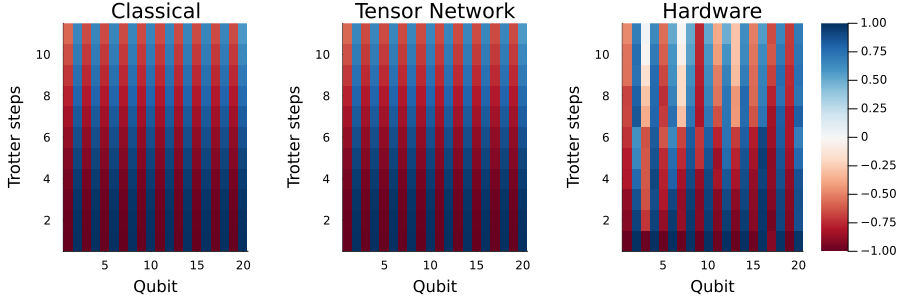

In [30]:
# plot magnetization as a function of time
l = @layout [a{0.3w} b{0.3w} c{0.44w}]
plot(
    heatmap(classical_magnetizations, title="Classical", clims=(-1,1), color=:RdBu,
        xlabel="Qubit", ylabel="Trotter steps", colorbar=false),
    heatmap(tn_magnetizations, title="Tensor Network", clims=(-1,1), color=:RdBu,
        xlabel="Qubit", ylabel="Trotter steps", colorbar=false),
    heatmap(magnetizations, title="Hardware", clims=(-1,1), color=:RdBu,
        xlabel="Qubit", ylabel="Trotter steps", colorbar=true),
    layout=l, size=(900,300),
    bottom_margin=5mm, left_margin=5mm, right_margin=6mm
)

## Large-scale hardware example

### Steps 1–4 in a single workflow
We now combine all four steps above into a single workflow, at a scale beyond the reach of exact classical simulation. Instead of resolving the magnetization site by site, we track a single scalar measure of antiferromagnetic order, the staggered magnetization:
$$
    \langle M_s \rangle = \frac{1}{N} \sum_{i=1}^{N} (-1)^i \langle Z_i \rangle
$$

The alternating sign in the summation makes the signal visible: for the Néel initial state $|0101\ldots01\rangle$ every term contributes $+1$, so $\langle M_s\rangle = 1$, whereas the plain average $\frac{1}{N}\sum_i \langle Z_i\rangle$ vanishes identically for all $t$. As the transverse field scrambles the alternating pattern, $\langle M_s\rangle$ decays toward $0$, so the staggered magnetization tells us how much of the initial order survives during the time evolution.

We also use this example to see how the Trotter step size affects accuracy. We fix the total evolution time $T = 1.5$ and vary the number of Trotter steps $r \in \{3, 6, 12\}$, so that $\delta t = T/r$. On hardware, two error sources compete: a smaller $\delta t$ reduces Trotter error, but requires a proportionally deeper circuit that accumulates more hardware noise.

In [31]:
# -------------------------Step 1-------------------------
# Map classical inputs to a quantum problem.
N_large = 60 # the hex outcomes are decoded into an Int64, so N_large must stay under 63 bits
@assert N_large < 63
g_large = named_grid((N_large,))
h_large = fill(1.0, N_large)       # transverse field on every site
J_large = fill(1.0, N_large - 1)   # nearest-neighbor ZZ couplings on the chain

T_total = 1.5                    # fixed total evolution time
r_list = [3, 6, 12]       # varying Trotter steps; δt = T_total/r
sweep = [(r, k) for r in r_list for k in 0:r]

qc_list_large = [make_trotter_circuit(h_large, J_large, N_large, T_total/r, k)
                 for (r, k) in sweep]

# -------------------------Step 2-------------------------
# Optimize the problem for quantum hardware execution.
tqc_list_large = [transpile(qc, target)[1] for qc in qc_list_large]
# Print the 2q depth of the deepest circuit at each δt\n",
for r in r_list
    i = findfirst(==((r, r)), sweep)   # the k = r circuit reaches the full T_total
    println("  δt = $(round(T_total/r, digits=4))  →  $(r+1) time points, ",
            "deepest circuit = $(r) Trotter steps, ",
            "2q depth = $(two_qubit_depth(tqc_list_large[i]))")
end

# -------------------------Step 3-------------------------
# Execute using Qiskit primitives.
shots_large = 4096

job_list_large = [run_sampler_job(service, backend, tqc, shots_large)
                  for tqc in tqc_list_large]

  δt = 0.5  →  4 time points, deepest circuit = 3 Trotter steps, 2q depth = 126
  δt = 0.25  →  7 time points, deepest circuit = 6 Trotter steps, 2q depth = 138
  δt = 0.125  →  13 time points, deepest circuit = 12 Trotter steps, 2q depth = 162


24-element Vector{QiskitIBMRuntime.Job}:
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000107c1d1e0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b8dd2ce0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b78f5cc0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b78f2510)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b78fa480)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b89bb110)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b89e74f0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b88b1880)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b78f7760)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004b78d06c0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @

In [34]:
# Run this cell to check the job status
# Run the following cell for post-processing after all jobs complete
for (i, job) in enumerate(job_list_large)
    r, k = sweep[i]
    println("Job $i (δt=$(round(T_total/r, digits=4)), k=$k): ",
            get_job_status(job, service))
end

Job 1 (δt=0.5, k=0): Completed
Job 2 (δt=0.5, k=1): Completed
Job 3 (δt=0.5, k=2): Completed
Job 4 (δt=0.5, k=3): Completed
Job 5 (δt=0.25, k=0): Completed
Job 6 (δt=0.25, k=1): Completed
Job 7 (δt=0.25, k=2): Completed
Job 8 (δt=0.25, k=3): Completed
Job 9 (δt=0.25, k=4): Completed
Job 10 (δt=0.25, k=5): Completed
Job 11 (δt=0.25, k=6): Completed
Job 12 (δt=0.125, k=0): Completed
Job 13 (δt=0.125, k=1): Completed
Job 14 (δt=0.125, k=2): Completed
Job 15 (δt=0.125, k=3): Completed
Job 16 (δt=0.125, k=4): Completed
Job 17 (δt=0.125, k=5): Completed
Job 18 (δt=0.125, k=6): Completed
Job 19 (δt=0.125, k=7): Completed
Job 20 (δt=0.125, k=8): Completed
Job 21 (δt=0.125, k=9): Completed
Job 22 (δt=0.125, k=10): Completed
Job 23 (δt=0.125, k=11): Completed
Job 24 (δt=0.125, k=12): Completed


In [35]:
# -------------------------Step 4-------------------------
# Post-process and return the result in the desired classical format.
# Run this cell after all jobs are completed

# ⟨M_s⟩ = (1/N) Σ (-1)^i ⟨Z_i⟩
staggered_magnetization(samples::AbstractVector{<:Integer}, n::Int) =
    sum((-1)^q * z_expval(samples, q) for q in 1:n) / n

all_samples_large = [get_sampler_job_results(job, service) for job in job_list_large]
all_ints_large = [parse.(Int, s) for s in all_samples_large]
mags_hardware = [staggered_magnetization(s, N_large) for s in all_ints_large]

24-element Vector{Float64}:
 0.9791666666666666
 0.6887451171875
 0.3953043619791667
 0.232275390625
 0.9804931640625
 0.7674235026041667
 0.5801839192708333
 0.37957356770833334
 0.2646402994791667
 0.180078125
 0.11245930989583333
 0.981787109375
 0.83056640625
 0.753076171875
 0.6288492838541667
 0.5119059244791667
 0.40411783854166666
 0.31669921875
 0.2547607421875
 0.20693359375
 0.16126302083333333
 0.12582194010416667
 0.11053873697916666
 0.08755696614583333

At $N=60$ the exact solution from the ODE solver used above is out of reach, because the state vector alone would need $2^{60} \approx 10^{18}$ amplitudes. Instead we use a noiseless tensor network simulation of the same 1D chain with a much finer Trotter step ($r = 96$, $\delta t \approx 0.016$) as the reference, where the Trotter error is negligible compared with any $\delta t$ we run on hardware. This reference is itself approximate: its dominant error is now the bond-dimension truncation discussed above, reported as a truncation fidelity for each run.

In [36]:
apply_kwargs = (; maxdim=64, cutoff=1e-10, normalize_tensors=true)

# Calculate the staggered magnetization given a tensor network state
staggered_magnetization(ψ_bpc::BeliefPropagationCache, n::Int) =
    sum((-1)^q * m for (q, m) in enumerate(z_expvals_from_tn_state(ψ_bpc, n))) / n

# Evolve a TN state and record the staggered magnetization at each step.
function compute_staggered_magnetization_tn(δt::Real, nsteps::Int; record_every::Int = 1)
    init_gates = neel_state_gates(N_large)
    step_gates = trotter_step_gates(h_large, J_large, N_large, δt)

    ψ_bpc, fid = apply_gates_to_tn_state(init_gates, tn_initial_state(g_large); apply_kwargs)
    times = [0.0]
    mags = [staggered_magnetization(ψ_bpc, N_large)]
    for k in 1:nsteps
        ψ_bpc, fid_step = apply_gates_to_tn_state(step_gates, ψ_bpc; apply_kwargs)
        fid *= fid_step
        if k % record_every == 0
            push!(times, k * δt)
            push!(mags, staggered_magnetization(ψ_bpc, N_large))
        end
    end
    println("  δt=$(round(δt, digits=5)), $(nsteps) steps: truncation fidelity ≈ $(round(fid, digits=5))")
    (times, mags)
end

# If the fidelity drifts from 1, raise `maxdim` in `apply_kwargs`.
println("Tensor-network reference:")
r_ref = 96
times_ref, mags_ref = compute_staggered_magnetization_tn(T_total / r_ref, r_ref; record_every = r_ref ÷ 12)

Tensor-network reference:
  δt=0.01562, 96 steps: truncation fidelity ≈ 1.0


([0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0, 1.125, 1.25, 1.375, 1.5], Float32[1.0, 0.96955144, 0.8869299, 0.7738875, 0.6549585, 0.54784936, 0.45952383, 0.38842976, 0.32962745, 0.2790362, 0.23493056, 0.19718494, 0.16583435])

The plot below shows the staggered magnetization over time for the three Trotter step sizes, against the noiseless tensor network reference (dashed black).

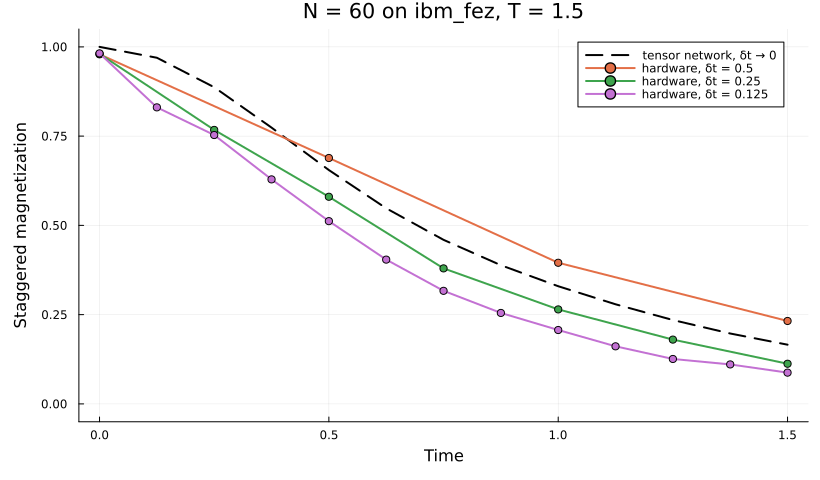

In [37]:
plt = plot(xlabel = "Time", ylabel = "Staggered magnetization",
    title = "N = $(N_large) on $(backend.name), T = $(T_total)",
    legend = :topright, ylims = (-0.05, 1.05), size = (820, 480),
    bottom_margin = 5mm, left_margin = 5mm)

# Plot tensor network reference
plot!(plt, times_ref, mags_ref, lw = 2, ls = :dash, color = :black,
      label = "tensor network, δt → 0")

# Plot hardware result per Trotter step size
for (r, stop) in zip(r_list, cumsum(r_list .+ 1))
    plot!(plt, range(0, T_total, length = r + 1), mags_hardware[(stop - r):stop],
          marker = :circle, markersize = 4, lw = 2,
          label = "hardware, δt = $(round(T_total / r, digits = 4))")
end
plt

At the coarsest Trotter step, $\delta t = 0.5$ (orange circles), the measured staggered magnetization lies above the reference at every subsequent sampled time point, which suggests a large Trotterization error. By contrast, hardware noise biases the result the other way, driving the staggered magnetization toward zero. This effect is clearest at short times for the finer Trotter steps, $\delta t = 0.25$ and $0.125$, where the hardware results lie below the reference.

Comparing $\delta t = 0.25$ (green circles) and $0.125$ (purple circles): halving the Trotter step doubles the circuit depth and in principle reduces the Trotter error, but the two hardware curves are similar, so the coarser of the two reaches the same accuracy at half the depth. Choosing $\delta t$ for a Trotterized circuit on hardware is therefore a trade-off between Trotter error and the noise accumulated in a deeper circuit.

## Next steps

If you found this work interesting, you might be interested in the following material:

* [Multi-product formulas to reduce Trotter error](https://quantum.cloud.ibm.com/docs/en/tutorials/multi-product-formula)

* [Integrating quantum and high-performance computing course](https://quantum.cloud.ibm.com/learning/en/courses/integrating-quantum-and-high-performance-computing)

* [Qiskit.jl](https://github.com/Qiskit/Qiskit.jl) and [QiskitIBMRuntime.jl](https://github.com/Qiskit/QiskitIBMRuntime.jl) on GitHub